<a href="https://colab.research.google.com/github/anthony-yt/wildfire-cellular-automata/blob/automata-celular_yosue_1/notebooks/prueba_diccionario_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importaciones:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [2]:
#Objetos de la matriz:

ESTADOS = {
    'BIOMASA': (0, 'green', 0.55),
    'FUEGO': (1, 'red', 0.00),
    'AGUA': (2, 'skyblue', 0.00),
    'CENIZA': (3, 'black', 0.00),
    'ROCA': (4, 'dimgray', 0.00),
    'HIERVA' : (5, 'gold', 0.85)
}
colores = []
ignicion = []

for datos in ESTADOS.values():
    colores.append(datos[1])
    ignicion.append(datos[2])

print(colores)
print(ignicion)

['green', 'red', 'skyblue', 'black', 'dimgray', 'gold']
[0.55, 0.0, 0.0, 0.0, 0.0, 0.85]


In [3]:
#Tamaño de la matriz:
tmn=50
mapa= np.zeros((tmn,tmn),dtype=int)

mapa[int(tmn/2),int(tmn/2)] = ESTADOS['FUEGO'][0]


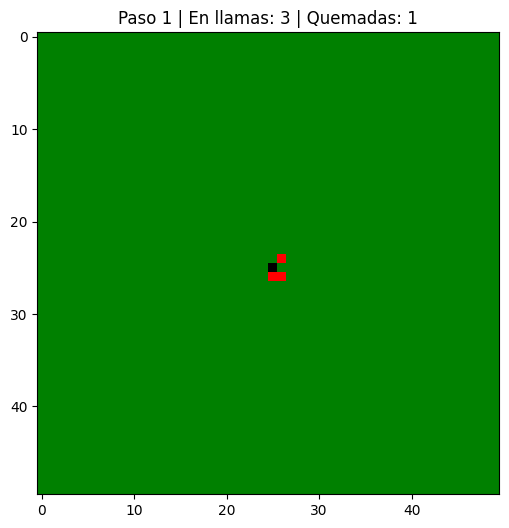

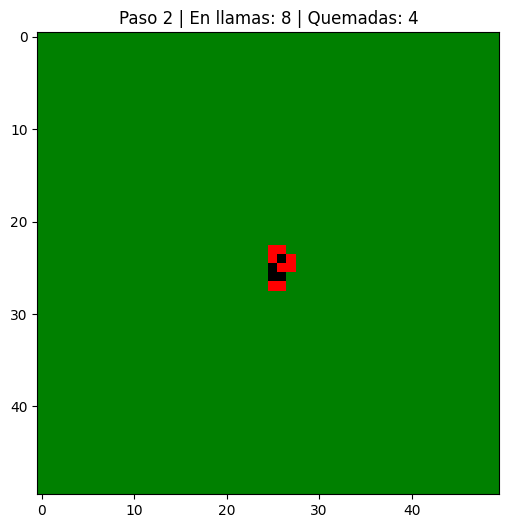

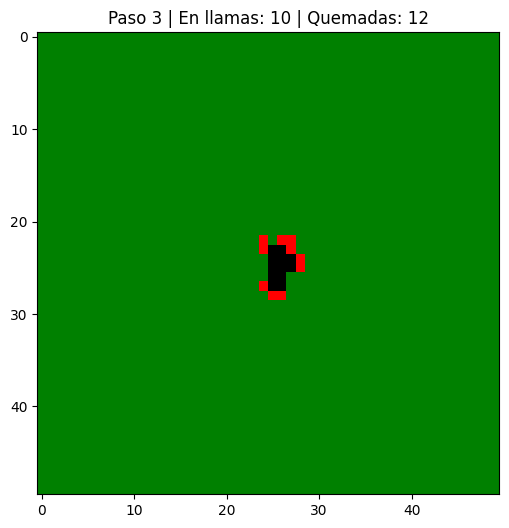

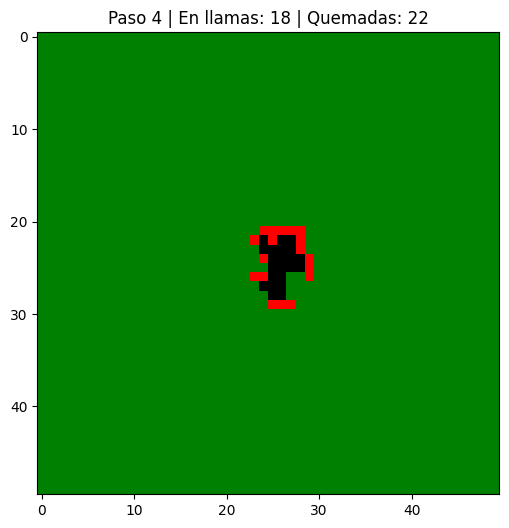

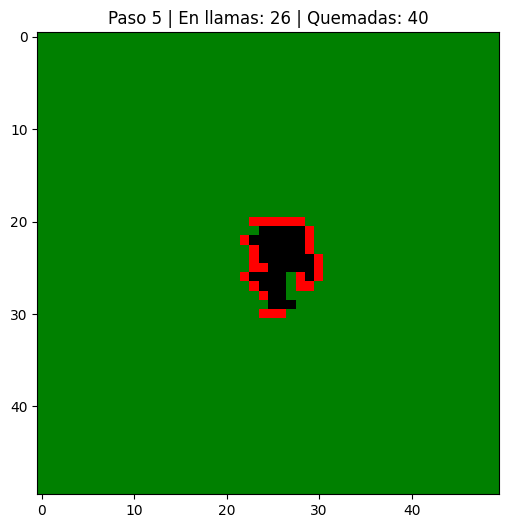

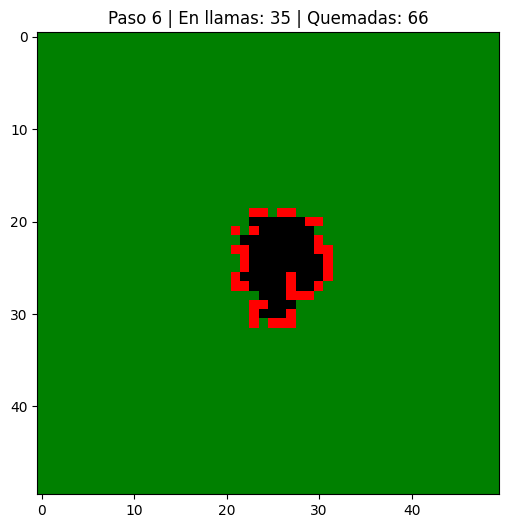

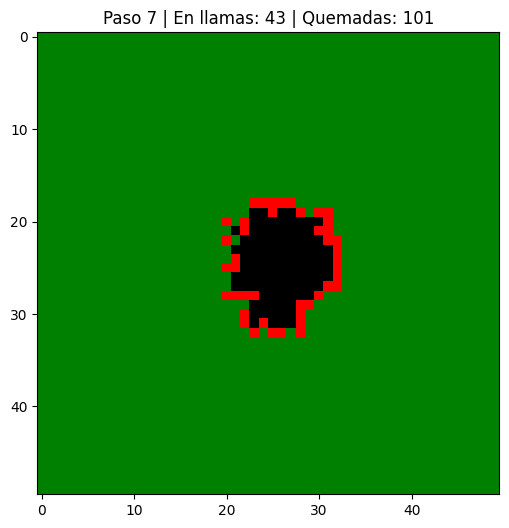

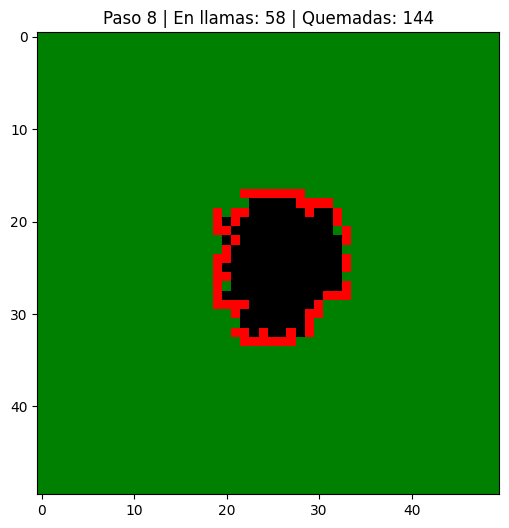

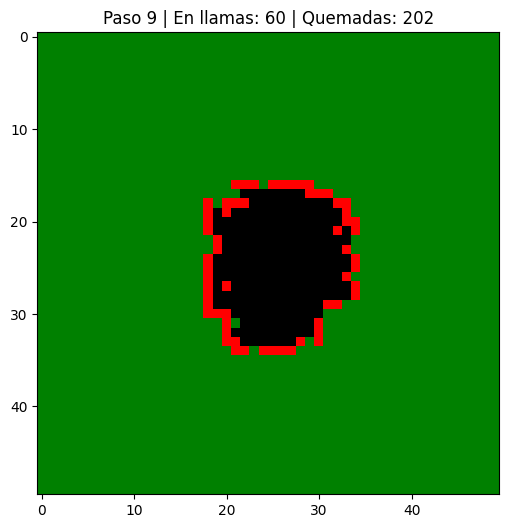

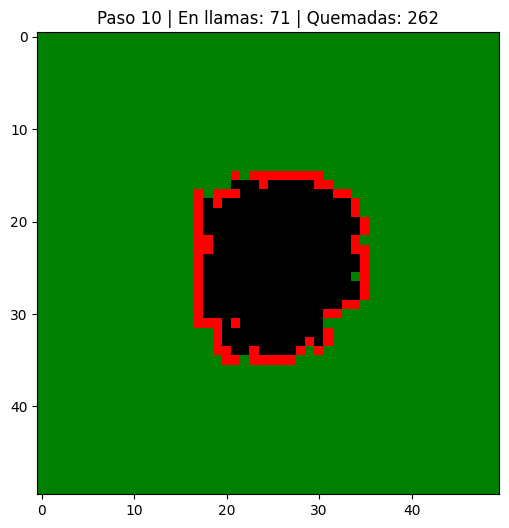

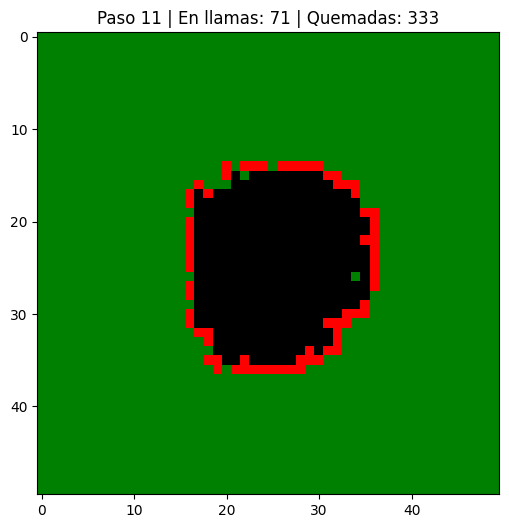

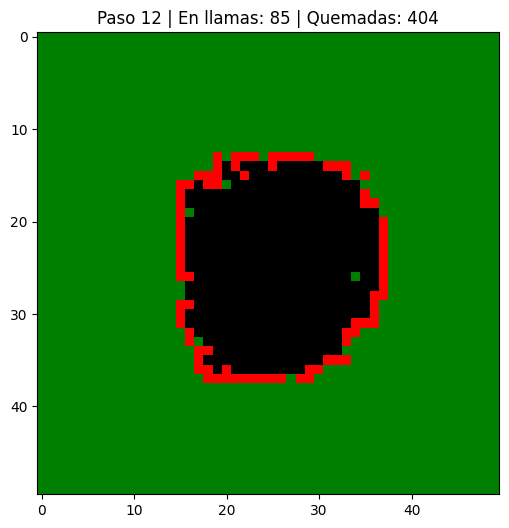

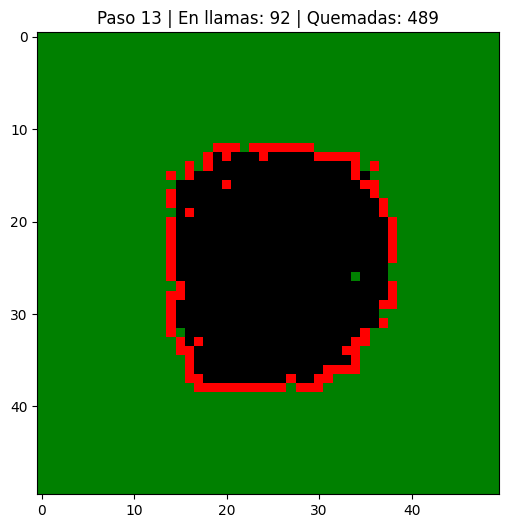

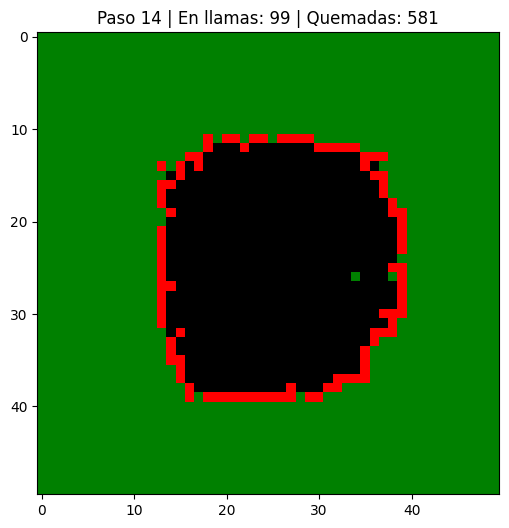

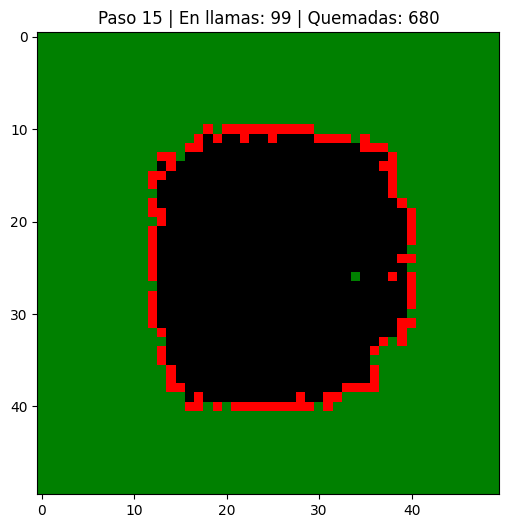

In [4]:
# Establecemos la propagación:
movimientos = [
    (-1, 0),  # Arriba
    (1, 0),   # Abajo
    (0, -1),  # Izquierda
    (0, 1),   # Derecha
    (-1, -1), # Diagonal Arriba-Izquierda
    (-1, 1),  # Diagonal Arriba-Derecha
    (1, -1),  # Diagonal Abajo-Izquierda
    (1, 1)    # Diagonal Abajo-Derecha
]

# Inflamables:
inflamable = [ESTADOS['BIOMASA'][0], ESTADOS['HIERVA'][0]]

pasos_totales = 15

for paso in range(pasos_totales):
    futuro = mapa.copy()
    for f in range(tmn):
        for c in range(tmn):
            if mapa[f, c] == ESTADOS['FUEGO'][0]:
                # El fuego se convierte en ceniza en el siguiente turno
                futuro[f, c] = ESTADOS['CENIZA'][0]

                # Evaluar propagación a los vecinos
                for df, dc in movimientos:
                    nf = f + df  # nueva fila
                    nc = c + dc  # nueva columna

                    # Verificar que el vecino esté dentro de los límites de la matriz
                    if 0 <= nf < tmn and 0 <= nc < tmn:
                        if mapa[nf, nc] in inflamable:
                            prob = ignicion[mapa[nf, nc]]
                            if np.random.rand() < prob:
                                futuro[nf, nc] = ESTADOS['FUEGO'][0]
    mapa = futuro

    celdas_quemadas = np.sum(mapa == ESTADOS['CENIZA'][0])
    celdas_en_fuego = np.sum(mapa == ESTADOS['FUEGO'][0])

    paleta = ListedColormap(colores)
    plt.figure(figsize=(6, 6))
    plt.imshow(mapa, cmap=paleta, vmin=0, vmax=len(colores)-1)
    plt.title(f'Paso {paso+1} | En llamas: {celdas_en_fuego} | Quemadas: {celdas_quemadas}')
    plt.show()

